# 04 Distribution Analysis

Research Question 3:

How do performance distributions change as players approach mastery?

Workflow:

1. Load `player_trajectories.csv`
2. Split each career into early (first 25%) and late (last 25%) phases
3. Compute distribution metrics (mean, std, skewness, kurtosis)
4. Plot early vs late distributions for one example player
5. Compare variability with `std_reduction = std_late / std_early`
6. Build population summary with paired tests
7. Save outputs

Outputs:

- `distribution_metrics.csv`
- `variability_comparison.csv`
- `distribution_summary.csv`
- `figures/example_distribution_overlay.png`

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import kurtosis, skew, ttest_rel, wilcoxon

ROOT = Path.cwd()
if not (ROOT / "data" / "processed").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_loading import processed_data_dir, results_data_dir

EXPERIMENT_NAME = "case_study_333_10players"
processed_dir = processed_data_dir(ROOT, experiment_name=EXPERIMENT_NAME)
results_dir = results_data_dir(ROOT, experiment_name=EXPERIMENT_NAME)
figures_dir = results_dir / "figures"

results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

trajectories_path = processed_dir / "player_trajectories.csv"
metrics_path = results_dir / "distribution_metrics.csv"
comparison_path = results_dir / "variability_comparison.csv"
summary_path = results_dir / "distribution_summary.csv"
example_plot_path = figures_dir / "example_distribution_overlay.png"

print(f"Trajectory input: {trajectories_path}")
print(f"Results dir: {results_dir}")
if not trajectories_path.exists():
    raise FileNotFoundError(f"Missing trajectory file: {trajectories_path}")

player_trajectories = pd.read_csv(trajectories_path, parse_dates=["competition_date"])
player_trajectories = player_trajectories.sort_values(["person_id", "seq_index"]).reset_index(drop=True)

time_col = "average_seconds"
if time_col not in player_trajectories.columns:
    raise ValueError(f"Expected column '{time_col}' not found in player_trajectories.csv")

print(f"Rows loaded: {len(player_trajectories)}")
print(f"Players loaded: {player_trajectories['person_id'].nunique()}")
display(player_trajectories.head())

Trajectory input: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\processed\case_study_333_10players\player_trajectories.csv
Results dir: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\case_study_333_10players
Rows loaded: 7056
Players loaded: 10


,person_id,person_name,competition_date,average_seconds,seq_index
0,2009LIUE01,Evan Liu,2009-05-30,44.77,1
1,2009LIUE01,Evan Liu,2009-08-14,33.30,2
2,2009LIUE01,Evan Liu,2010-01-30,20.28,3
3,2009LIUE01,Evan Liu,2010-01-30,21.71,4
4,2009LIUE01,Evan Liu,2010-04-18,20.91,5


## Phase Splitting & Metric Calculation

We isolate the first 25% and last 25% of each player's trajectory. 
* The **Early Phase** captures the cognitive and motor exploration period, characterized by high variance and frequent mistakes (heavy right-skew).
* The **Late Phase** represents autonomous, stabilized execution, characterized not just by faster averages, but by a drastic reduction in execution variance.

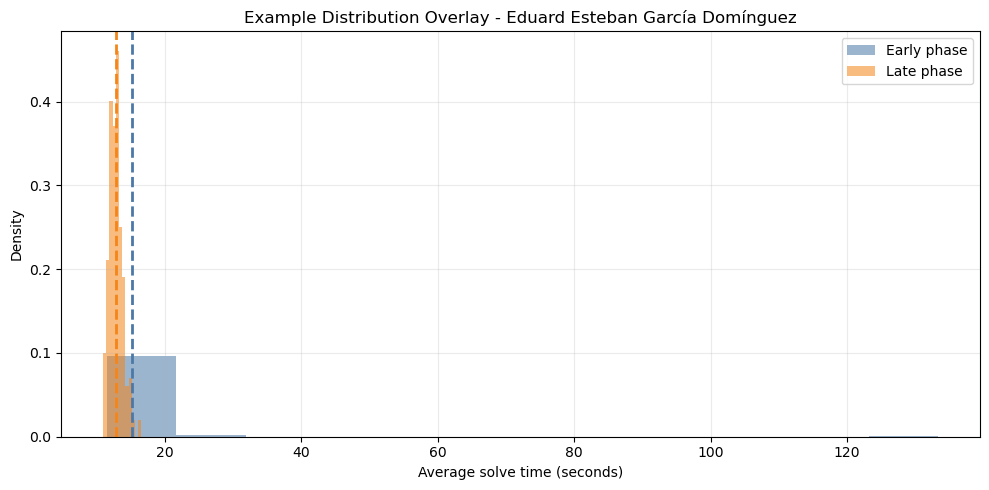

Saved distribution metrics to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\case_study_333_10players\distribution_metrics.csv
Saved variability comparison to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\case_study_333_10players\variability_comparison.csv
Saved summary to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\case_study_333_10players\distribution_summary.csv
Saved example distribution figure to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\case_study_333_10players\figures\example_distribution_overlay.png


In [4]:
metrics_rows = []
comparison_rows = []
skipped_players = []

for person_id, group in player_trajectories.groupby("person_id", sort=False):
    group = group.sort_values("seq_index").reset_index(drop=True)
    player_name = group["person_name"].iloc[0]
    n_obs = len(group)
    # Isolate the first and last 25% of the career
    phase_n = n_obs // 4

    if phase_n < 3:
        skipped_players.append({"person_id": person_id, "reason": "too_few_observations"})
        continue

    early = group.iloc[:phase_n].copy()
    late = group.iloc[-phase_n:].copy()

    def phase_stats(values):
        """Helper to calculate distributional moments."""
        values = np.asarray(values, dtype=float)
        return {
            "mean": float(np.mean(values)),
            "std": float(np.std(values, ddof=1)) if len(values) > 1 else float("nan"),
            "skewness": float(skew(values, bias=False)) if len(values) > 2 else float("nan"),
            "kurtosis": float(kurtosis(values, fisher=True, bias=False)) if len(values) > 3 else float("nan"),
        }

    early_stats = phase_stats(early[time_col].to_numpy())
    late_stats = phase_stats(late[time_col].to_numpy())

    metrics_rows.append({
        "person_id": person_id,
        "person_name": player_name,
        "phase": "early",
        "n_phase": int(len(early)),
        **early_stats,
    })
    metrics_rows.append({
        "person_id": person_id,
        "person_name": player_name,
        "phase": "late",
        "n_phase": int(len(late)),
        **late_stats,
    })

    # Calculate Shrinkage (Variance Reduction)
    std_early = early_stats["std"]
    std_late = late_stats["std"]
    std_ratio = float(std_late / std_early) if np.isfinite(std_early) and std_early > 0 else float("nan")
    variability_reduction_pct = float(1 - std_ratio) if np.isfinite(std_ratio) else float("nan")

    comparison_rows.append({
        "person_id": person_id,
        "person_name": player_name,
        "n_obs": int(n_obs),
        "phase_n": int(phase_n),
        "mean_early": early_stats["mean"],
        "mean_late": late_stats["mean"],
        "std_early": std_early,
        "std_late": std_late,
        "std_ratio": std_ratio,
        "variability_reduction_pct": variability_reduction_pct,
        "skewness_early": early_stats["skewness"],
        "skewness_late": late_stats["skewness"],
        "kurtosis_early": early_stats["kurtosis"],
        "kurtosis_late": late_stats["kurtosis"],
    })


distribution_metrics = pd.DataFrame(metrics_rows)
variability_comparison = pd.DataFrame(comparison_rows)

if not distribution_metrics.empty:
    distribution_metrics = distribution_metrics.sort_values(["person_id", "phase"]).reset_index(drop=True)
if not variability_comparison.empty:
    variability_comparison = variability_comparison.sort_values("std_ratio").reset_index(drop=True)

example_plot_saved = False
if not player_trajectories.empty:
    example_person_id = variability_comparison.sort_values(["n_obs", "std_ratio"], ascending=[False, True]).iloc[0]["person_id"] if not variability_comparison.empty else player_trajectories["person_id"].iloc[0]
    example_player = player_trajectories.loc[player_trajectories["person_id"] == example_person_id].sort_values("seq_index").reset_index(drop=True)
    if not example_player.empty:
        n_obs = len(example_player)
        phase_n = n_obs // 4
        if phase_n >= 3:
            early_example = example_player.iloc[:phase_n].copy()
            late_example = example_player.iloc[-phase_n:].copy()

            fig, ax = plt.subplots(figsize=(10, 5))
            ax.hist(early_example[time_col], bins=12, alpha=0.55, label="Early phase", color="#4C78A8", density=True)
            ax.hist(late_example[time_col], bins=12, alpha=0.55, label="Late phase", color="#F58518", density=True)
            ax.axvline(float(np.mean(early_example[time_col])), color="#4C78A8", linestyle="--", linewidth=2)
            ax.axvline(float(np.mean(late_example[time_col])), color="#F58518", linestyle="--", linewidth=2)
            ax.set_title(f"Example Distribution Overlay - {example_player['person_name'].iloc[0]}")
            ax.set_xlabel("Average solve time (seconds)")
            ax.set_ylabel("Density")
            ax.legend()
            ax.grid(True, alpha=0.25)
            fig.tight_layout()
            fig.savefig(example_plot_path, dpi=200, bbox_inches="tight")
            plt.show()
            example_plot_saved = True

# Population-level paired tests across players
# (one paired observation per player: std_early vs std_late)
t_stat = t_pval = w_stat = w_pval = float("nan")
if not variability_comparison.empty:
    early_std = variability_comparison["std_early"].to_numpy(dtype=float)
    late_std = variability_comparison["std_late"].to_numpy(dtype=float)
    valid = np.isfinite(early_std) & np.isfinite(late_std)

    if valid.sum() >= 2:
        t_stat, t_pval = ttest_rel(early_std[valid], late_std[valid])
        try:
            w_stat, w_pval = wilcoxon(early_std[valid], late_std[valid])
        except ValueError:
            w_stat, w_pval = float("nan"), float("nan")

# Test for Statistical Significance
summary_rows = []
if not variability_comparison.empty:
    summary_rows.extend(
        [
            {"metric": "players_analyzed", "value": float(len(variability_comparison))},
            {"metric": "mean_std_early", "value": float(np.nanmean(variability_comparison["std_early"]))},
            {"metric": "mean_std_late", "value": float(np.nanmean(variability_comparison["std_late"]))},
            {"metric": "mean_std_ratio", "value": float(np.nanmean(variability_comparison["std_ratio"]))},
            {"metric": "mean_variability_reduction_pct", "value": float(np.nanmean(variability_comparison["variability_reduction_pct"]))},
            {"metric": "share_with_reduced_variability", "value": float(np.mean(variability_comparison["std_ratio"] < 1))},
            {"metric": "paired_t_stat", "value": float(t_stat)},
            {"metric": "paired_t_pvalue", "value": float(t_pval)},
            {"metric": "wilcoxon_stat", "value": float(w_stat)},
            {"metric": "wilcoxon_pvalue", "value": float(w_pval)},
        ]
    )

summary_df = pd.DataFrame(summary_rows)

summary_df.to_csv(summary_path, index=False)
variability_comparison.to_csv(comparison_path, index=False)
distribution_metrics.to_csv(metrics_path, index=False)

print(f"Saved distribution metrics to: {metrics_path}")
print(f"Saved variability comparison to: {comparison_path}")
print(f"Saved summary to: {summary_path}")
if example_plot_saved:
    print(f"Saved example distribution figure to: {example_plot_path}")

In [5]:
# Numeric outputs for the report (in addition to the overlay plot)
print("Distribution summary metrics:")
display(summary_df)

key_metrics = ["paired_t_stat", "paired_t_pvalue", "wilcoxon_stat", "wilcoxon_pvalue"]
sig_table = summary_df.loc[summary_df["metric"].isin(key_metrics)].copy()
if not sig_table.empty:
    print("\nSignificance tests:")
    display(sig_table)

print("\nTop rows of early/late comparison table:")
display(
    variability_comparison[
        [
            "person_id",
            "person_name",
            "n_obs",
            "std_early",
            "std_late",
            "std_ratio",
            "variability_reduction_pct",
        ]
    ].head(10)
)

print(f"Saved summary csv: {summary_path}")
print(f"Saved comparison csv: {comparison_path}")

Distribution summary metrics:


,metric,value
0,players_analyzed,10.000000
1,mean_std_early,3.135746
2,mean_std_late,0.688054
3,mean_std_ratio,0.266839
4,mean_variability_reduction_pct,0.733161
5,share_with_reduced_variability,1.000000
6,paired_t_stat,3.980065
7,paired_t_pvalue,0.003205
8,wilcoxon_stat,0.000000
9,wilcoxon_pvalue,0.001953



Significance tests:


,metric,value
6,paired_t_stat,3.980065
7,paired_t_pvalue,0.003205
8,wilcoxon_stat,0.000000
9,wilcoxon_pvalue,0.001953



Top rows of early/late comparison table:


,person_id,person_name,n_obs,std_early,std_late,std_ratio,variability_reduction_pct
0,2011EDUA01,Eduard Esteban García Domínguez,860,8.417348,0.969133,0.115135,0.884865
1,2012PARK03,Max Park,617,2.607982,0.400938,0.153735,0.846265
2,2012MAHV01,Paul Mahvi,701,3.743955,0.587667,0.156964,0.843036
3,2009LIUE01,Evan Liu,700,3.794821,0.765819,0.201806,0.798194
4,2009PROV01,Matteo Provasi,750,3.471326,0.751403,0.216460,0.783540
5,2010HULL01,Katie Hull,684,1.808479,0.587151,0.324666,0.675334
6,2013WALL03,Daniel Wallin,711,1.980837,0.678043,0.342301,0.657699
7,2014ZAKR01,Karol Zakrzewski,648,1.542823,0.576513,0.373674,0.626326
8,2013ROGA02,Przemysław Rogalski,626,1.915331,0.744072,0.388482,0.611518
9,2010ROSE03,Dennis Rosero,759,2.074556,0.819799,0.395168,0.604832


Saved summary csv: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\case_study_333_10players\distribution_summary.csv
Saved comparison csv: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\case_study_333_10players\variability_comparison.csv


## Interpretation Guide

Key interpretation targets for RQ3:

- Lower `mean` in late phase indicates better average performance.
- `std_reduction < 1` indicates variability shrank toward mastery.
- Skewness moving toward 0 suggests more symmetric distributions.
- Lower excess kurtosis suggests fewer heavy-tail outliers.
- Significant paired-test p-values support a systematic population-level change in variability.

## Conclusion: The Shrinkage of Variability

* **Variance Reduction:** As players transitioned from early learning to late mastery, their performance variability collapsed. On average, the standard deviation shrunk by **73.3%** (Mean STD Ratio = 0.26). 
* **Universality:** This variance reduction occurred in **100%** of the analyzed players.
* **Statistical Significance:** The reduction in variance is highly statistically significant at the population level, supported by both parametric (Paired t-test $p = 0.003$) and non-parametric measures (Wilcoxon signed-rank $p = 0.0019$). 
* **Distributional Shape:** Learning does not merely shift the mean to the left, it alters the shape of the distribution. Early distributions are heavily right-skewed with extreme outliers (average skewness = 3.96, kurtosis = 30.9). Late distributions are tightly bound and symmetric (average skewness = 0.67, kurtosis = 1.64.